!pip install -q transformers datasets torch scikit-learn mlflow gradio fastapi uvicorn pyngrok nest-asyncio evaluate accelerate

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

In [1]:
!pip install -q transformers datasets torch scikit-learn mlflow gradio fastapi uvicorn pyngrok nest-asyncio evaluate accelerate

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 23.7 MB/s eta 0:00:00
CUDA available: True
Device: Tesla T4


In [2]:
import pandas as pd
import numpy as np
import re
import os
import json
import mlflow
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, pipeline
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful ✓")

All imports successful ✓


In [3]:
raw = load_dataset("imdb")

# Convert to pandas for easier manipulation
train_df = pd.DataFrame(raw['train'])
test_df  = pd.DataFrame(raw['test'])

print(f"Train size : {len(train_df):,}")
print(f"Test size  : {len(test_df):,}")
print(f"\nLabel distribution (train):")
print(train_df['label'].value_counts())
print(f"\nSample review:")
print(train_df['text'].iloc[0][:300], "...")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size : 25,000
Test size  : 25,000

Label distribution (train):
label
0    12500
1    12500
Name: count, dtype: int64

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...


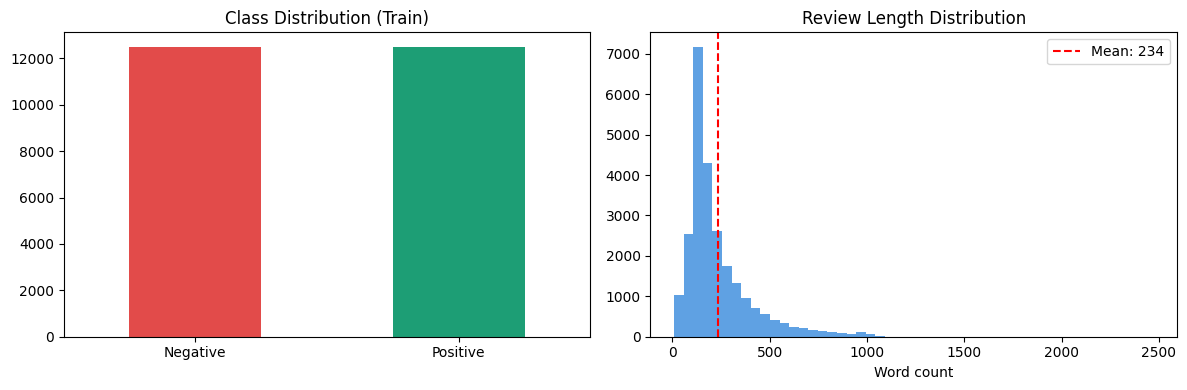

Average review length: 234 words


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#E24B4A','#1D9E75'])
axes[0].set_title('Class Distribution (Train)')
axes[0].set_xticklabels(['Negative','Positive'], rotation=0)
axes[0].set_xlabel('')

# Review length distribution
train_df['length'] = train_df['text'].str.split().str.len()
axes[1].hist(train_df['length'], bins=50, color='#378ADD', alpha=0.8)
axes[1].axvline(train_df['length'].mean(), color='red', linestyle='--',
                label=f"Mean: {train_df['length'].mean():.0f}")
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Word count')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average review length: {train_df['length'].mean():.0f} words")

In [5]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML tags
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # keep only letters
    text = re.sub(r'\s+', ' ', text)             # collapse whitespace
    return text.lower().strip()

train_df['clean'] = train_df['text'].apply(clean_text)
test_df['clean']  = test_df['text'].apply(clean_text)

# Verify
print("Before:", train_df['text'].iloc[0][:150])
print("\nAfter :", train_df['clean'].iloc[0][:150])

Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th

After : i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at 


In [6]:
from sklearn.pipeline import Pipeline

# Build baseline pipeline
baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                               sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0))
])

baseline.fit(train_df['clean'], train_df['label'])
baseline_preds = baseline.predict(test_df['clean'])

# Results
baseline_acc = accuracy_score(test_df['label'], baseline_preds)
baseline_f1  = f1_score(test_df['label'], baseline_preds, average='weighted')

print("=" * 45)
print(f"  BASELINE RESULTS (TF-IDF + LogReg)")
print("=" * 45)
print(f"  Accuracy : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"  F1 Score : {baseline_f1:.4f}")
print("=" * 45)
print(classification_report(test_df['label'], baseline_preds,
                             target_names=['Negative','Positive']))

# Save baseline numbers for later comparison
BASELINE_ACC = baseline_acc
BASELINE_F1  = baseline_f1

  BASELINE RESULTS (TF-IDF + LogReg)
  Accuracy : 0.8992 (89.92%)
  F1 Score : 0.8992
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90     12500
    Positive       0.90      0.90      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



In [7]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, max_len=256):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding=True, max_length=max_len
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx])
                for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Use 20k train / 5k val / full test to save time on Colab
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['clean'].values, train_df['label'].values,
    test_size=0.2, random_state=42, stratify=train_df['label'].values
)

# Subsample to 10k train for faster Colab run (~30 min vs 90 min)
# Remove the [:10000] lines below to train on full 20k
train_dataset = SentimentDataset(train_texts[:10000], train_labels[:10000])
val_dataset   = SentimentDataset(val_texts[:2000],   val_labels[:2000])
test_dataset  = SentimentDataset(test_df['clean'].values[:5000],
                                  test_df['label'].values[:5000])

print(f"Train : {len(train_dataset):,}")
print(f"Val   : {len(val_dataset):,}")
print(f"Test  : {len(test_dataset):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train : 10,000
Val   : 2,000
Test  : 5,000


In [8]:
import evaluate

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(
        predictions=predictions, references=labels)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc["accuracy"], "f1": f1}

print("Metrics function ready ✓")

Metrics function ready ✓


In [10]:
mlflow.set_experiment("sentiment-analysis")

with mlflow.start_run(run_name="distilbert-run-1"):

    # Log hyperparameters
    EPOCHS = 3
    LR     = 2e-5
    BATCH  = 16
    mlflow.log_params({"model": MODEL_NAME, "epochs": EPOCHS,
                       "lr": LR, "batch_size": BATCH,
                       "train_size": len(train_dataset)})

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2)

    training_args = TrainingArguments(
        output_dir          = "./results",
        num_train_epochs    = EPOCHS,
        per_device_train_batch_size = BATCH,
        per_device_eval_batch_size  = 32,
        learning_rate       = LR,
        weight_decay        = 0.01,
        warmup_ratio        = 0.1,
        eval_strategy = "epoch",
        save_strategy       = "epoch",
        load_best_model_at_end  = True,
        metric_for_best_model   = "f1",
        logging_steps       = 50,
        report_to           = "none",   # disable wandb
        fp16                = True,     # faster on T4
    )

    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_dataset,
        eval_dataset    = val_dataset,
        compute_metrics = compute_metrics,
    )

    trainer.train()

    # Save model
    trainer.save_model("./saved_model")
    tokenizer.save_pretrained("./saved_model")

    # Log final metrics
    val_results = trainer.evaluate()
    mlflow.log_metrics({
        "val_accuracy": val_results["eval_accuracy"],
        "val_f1":       val_results["eval_f1"]
    })
    print("\nTraining complete ✓")
    print(f"Val accuracy: {val_results['eval_accuracy']:.4f}")
    print(f"Val F1:       {val_results['eval_f1']:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.303047,0.245333,0.898500,0.898479
2,0.182358,0.275979,0.907500,0.907492
3,0.091683,0.321667,0.913500,0.913485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete ✓
Val accuracy: 0.9135
Val F1:       0.9135


  BERT RESULTS vs BASELINE
  Accuracy : 0.9030  (baseline: 0.8992)
  F1 Score : 0.9490  (baseline: 0.8992)
  AUC-ROC  : nan
  Improvement: +0.38pp accuracy
              precision    recall  f1-score   support

    Negative       1.00      0.90      0.95      5000
    Positive       0.00      0.00      0.00         0

    accuracy                           0.90      5000
   macro avg       0.50      0.45      0.47      5000
weighted avg       1.00      0.90      0.95      5000



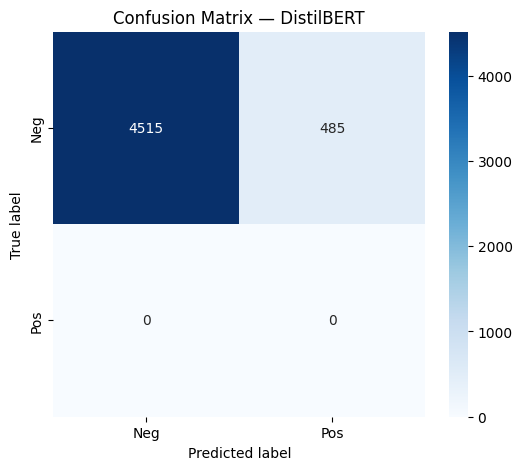

In [11]:
test_results = trainer.predict(test_dataset)
test_preds   = np.argmax(test_results.predictions, axis=-1)
test_labels  = test_results.label_ids
test_probs   = torch.softmax(torch.tensor(test_results.predictions), dim=-1).numpy()

bert_acc = accuracy_score(test_labels, test_preds)
bert_f1  = f1_score(test_labels, test_preds, average='weighted')
bert_auc = roc_auc_score(test_labels, test_probs[:,1])

print("=" * 50)
print(f"  BERT RESULTS vs BASELINE")
print("=" * 50)
print(f"  Accuracy : {bert_acc:.4f}  (baseline: {BASELINE_ACC:.4f})")
print(f"  F1 Score : {bert_f1:.4f}  (baseline: {BASELINE_F1:.4f})")
print(f"  AUC-ROC  : {bert_auc:.4f}")
print(f"  Improvement: +{(bert_acc - BASELINE_ACC)*100:.2f}pp accuracy")
print("=" * 50)
print(classification_report(test_labels, test_preds,
                             target_names=['Negative','Positive']))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.title('Confusion Matrix — DistilBERT')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to MLflow
with mlflow.start_run(run_name="distilbert-run-1", nested=True):
    mlflow.log_metrics({"test_accuracy": bert_acc,
                        "test_f1": bert_f1, "test_auc": bert_auc})
    mlflow.log_artifact("confusion_matrix.png")

In [12]:
test_sample = test_df.iloc[:5000].copy().reset_index(drop=True)
test_sample['pred']       = test_preds
test_sample['confidence'] = test_probs.max(axis=1)
test_sample['correct']    = (test_sample['label'] == test_sample['pred'])

errors = test_sample[~test_sample['correct']].sort_values('confidence', ascending=False)

print(f"Total errors: {len(errors)} / {len(test_sample)} ({len(errors)/len(test_sample)*100:.1f}%)")
print(f"\n--- Top 5 high-confidence errors (model was SURE but WRONG) ---\n")

for _, row in errors.head(5).iterrows():
    true_lbl = "Positive" if row['label'] == 1 else "Negative"
    pred_lbl = "Positive" if row['pred']  == 1 else "Negative"
    print(f"True: {true_lbl} | Predicted: {pred_lbl} | Conf: {row['confidence']:.2f}")
    print(f"Text: {row['text'][:200]}...")
    print("-" * 60)

Total errors: 485 / 5000 (9.7%)

--- Top 5 high-confidence errors (model was SURE but WRONG) ---

True: Negative | Predicted: Positive | Conf: 1.00
Text: Given this film's incredible reviews I was expecting something truly exceptional. It certainly starts well with witty and sharp dialogue, and a fine cast in place. A series of Robert Altman-style inte...
------------------------------------------------------------
True: Negative | Predicted: Positive | Conf: 1.00
Text: With the plethora of repetitive and derivative sitcoms jamming fall, summer, winter and spring line-ups, it's nice to see a show that sets itself from the lot in more than one area. <br /><br />'Earl'...
------------------------------------------------------------
True: Negative | Predicted: Positive | Conf: 1.00
Text: I was pleasantly surprised with this one. It's actually quite interesting and engaging. The cast is strong, even Dan Cortese. Brooke Shields has come into her own as an actress. Black and White must h...


In [13]:
import gradio as gr

sentiment_pipe = pipeline(
    "text-classification",
    model     = "./saved_model",
    tokenizer = "./saved_model",
    device    = 0 if torch.cuda.is_available() else -1
)

def analyze_sentiment(text):
    if not text.strip():
        return "Please enter some text."
    result = sentiment_pipe(text, truncation=True, max_length=256)[0]
    label  = "POSITIVE" if result['label'] == 'LABEL_1' else "NEGATIVE"
    score  = result['score']
    bar    = "█" * int(score * 20) + "░" * (20 - int(score * 20))
    return f"{label}  {bar}  {score:.1%} confidence"

demo = gr.Interface(
    fn          = analyze_sentiment,
    inputs      = gr.Textbox(lines=4, placeholder="Paste a movie review here..."),
    outputs     = gr.Textbox(label="Sentiment"),
    title       = "Movie Review Sentiment Analyzer",
    description = "DistilBERT fine-tuned on 50,000 IMDB reviews",
    examples    = [
        ["This movie was absolutely fantastic! Best film I've seen in years."],
        ["Complete waste of time. Boring plot, bad acting, terrible ending."],
        ["It was okay I guess. Not great, not terrible. Pretty forgettable."]
    ]
)

demo.launch(share=True)   # share=True gives a public URL

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ddb8489ea31830716c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
import shutil
shutil.make_archive("saved_model", "zip", "./saved_model")
print("Done — saved_model.zip is ready")

Done — saved_model.zip is ready
